In [82]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle

torch.set_default_dtype(torch.float64)

In [83]:
with open('/Users/anshgrover/AIDA3/PINN-tutorial/data/massdamper_data.pkl', 'rb') as f:
    data = pickle.load(f)

data_sampled_random_with_noise = data['data_sampled_random_with_noise']
model_name = 'No external force'
sparsity   = 'sparsity 1.667Hz'

t_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['t'], dtype=torch.float64)
y_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['x'], dtype=torch.float64)
n = len(t_obs)

delta_true  = 0.075
omega0_true = 0.3162
sigma_obs   = 0.1

print(f"n = {n}, t range: [{t_obs[0]:.2f}, {t_obs[-1]:.2f}]")

n = 100, t range: [0.00, 60.00]


In [84]:
def k_val(u, log_sigma_f2, log_l):
    sigma_f2 = torch.exp(log_sigma_f2)
    l = torch.exp(log_l)
    return sigma_f2 * torch.exp(-u**2 / (2*l))

def k_d1(u, log_sigma_f2, log_l):   # k'(u)
    l = torch.exp(log_l)
    return -(u/l) * k_val(u, log_sigma_f2, log_l)

def k_d2(u, log_sigma_f2, log_l):   # k''(u)
    l = torch.exp(log_l)
    return (u**2/l**2 - 1/l) * k_val(u, log_sigma_f2, log_l)

def k_d3(u, log_sigma_f2, log_l):   # k'''(u)
    l = torch.exp(log_l)
    return (3*u/l**2 - u**3/l**3) * k_val(u, log_sigma_f2, log_l)

def k_d4(u, log_sigma_f2, log_l):   # k''''(u)
    l = torch.exp(log_l)
    return (3/l**2 - 6*u**2/l**3 + u**4/l**4) * k_val(u, log_sigma_f2, log_l)

In [85]:
def pairwise_diff(t1, t2):
    return t1.unsqueeze(1) - t2.unsqueeze(0)   # u_ij = t1_i - t2_j

In [86]:
def build_covariance_blocks(t, log_sigma_f2, log_l):
    u = pairwise_diff(t, t)

    C_xx     =  k_val(u, log_sigma_f2, log_l)
    C_xdotx  =  k_d1(u, log_sigma_f2, log_l)      # cov(xdot, x')
    C_xxdot  = -k_d1(u, log_sigma_f2, log_l)      # cov(x, xdot')
    C_xdotxdot = -k_d2(u, log_sigma_f2, log_l)    # cov(xdot, xdot')

    C_xddotx =  k_d2(u, log_sigma_f2, log_l)      # cov(xddot, x')
    C_xxddot =  k_d2(u, log_sigma_f2, log_l)      # cov(x, xddot')
    C_xdotxddot =  k_d3(u, log_sigma_f2, log_l)   # cov(xdot, xddot')
    C_xddotxdot = -k_d3(u, log_sigma_f2, log_l)   # cov(xddot, xdot')
    C_xddotxddot = k_d4(u, log_sigma_f2, log_l)   # cov(xddot, xddot')

    return {
        'xx': C_xx, 'xxdot': C_xxdot, 'xdotx': C_xdotx, 'xdotxdot': C_xdotxdot,
        'xddotx': C_xddotx, 'xxddot': C_xxddot,
        'xdotxddot': C_xdotxddot, 'xddotxdot': C_xddotxdot, 'xddotxddot': C_xddotxddot,
    }

In [87]:
def xdot_given_x_conditional(x, mu_phi, C, jitter=1e-6):
    n = C['xx'].shape[0]
    C_xx_j = C['xx'] + jitter * torch.eye(n)
    L = torch.linalg.cholesky(C_xx_j)
    rhs = (x - mu_phi).unsqueeze(1)
    solved = torch.cholesky_solve(rhs, L).squeeze(1)
    m_xdot_given_x = C['xdotx'] @ solved
    Sigma_xdot_given_x = C['xdotxdot'] - C['xdotx'] @ torch.cholesky_solve(C['xxdot'], L)
    return m_xdot_given_x, Sigma_xdot_given_x

In [88]:
def log_likelihood_y_given_x(x, delta, omega0, mu_phi, sigma2_obs, C, jitter=1e-6):
    n = len(x)
    I = torch.eye(n)

    A = -2 * delta * I
    c_x = -omega0**2 * x

    B = torch.cat([
        torch.cat([C['xdotxdot'], C['xdotxddot']], dim=1),
        torch.cat([C['xddotxdot'], C['xddotxddot']], dim=1)
    ], dim=0)
    B_j = B + jitter * torch.eye(2*n)
    L_B = torch.linalg.cholesky(B_j) 

    C_x_row = torch.cat([C['xxdot'], C['xxddot']], dim=1)
    stacked_I_A = torch.cat([I, A], dim=0)

    M = C_x_row @ torch.cholesky_solve(stacked_I_A, L_B)

    zero_c = torch.cat([torch.zeros(n), c_x]).unsqueeze(1)
    a0 = mu_phi + (C_x_row @ torch.cholesky_solve(zero_c, L_B)).squeeze(1)

    C_xx_col = torch.cat([C['xdotx'], C['xddotx']], dim=0)
    Sigma_y = C['xx'] - C_x_row @ torch.cholesky_solve(C_xx_col, L_B) + sigma2_obs * I

    m_xdot_given_x, Sigma_xdot_given_x = xdot_given_x_conditional(x, mu_phi, C, jitter=jitter)

    mean_y = M @ m_xdot_given_x + a0
    cov_y  = Sigma_y + M @ Sigma_xdot_given_x @ M.T
    cov_y = (cov_y + cov_y.T) / 2 + jitter * torch.eye(n)

    dist = torch.distributions.MultivariateNormal(mean_y, covariance_matrix=cov_y)
    return dist

In [89]:
mu_phi_test = y_obs.mean()
log_sigma_f2_test = torch.tensor(0.0)
log_l_test = torch.tensor(np.log(5.0))
sigma2_test = 0.01

C_test = build_covariance_blocks(t_obs, log_sigma_f2_test, log_l_test)
dist_test = log_likelihood_y_given_x(y_obs, delta_true, omega0_true, mu_phi_test, sigma2_test, C_test)

ll = dist_test.log_prob(y_obs)
print(f"log p(y | x=y_obs, theta_true, phi_test) = {ll.item():.2f}")
print(f"mean_y range: [{dist_test.mean.min():.3f}, {dist_test.mean.max():.3f}]")
print(f"cov_y diagonal range: [{torch.diagonal(dist_test.covariance_matrix).min():.4f}, {torch.diagonal(dist_test.covariance_matrix).max():.4f}]")

log p(y | x=y_obs, theta_true, phi_test) = 98.89
mean_y range: [-0.913, 0.760]
cov_y diagonal range: [0.0929, 0.0932]


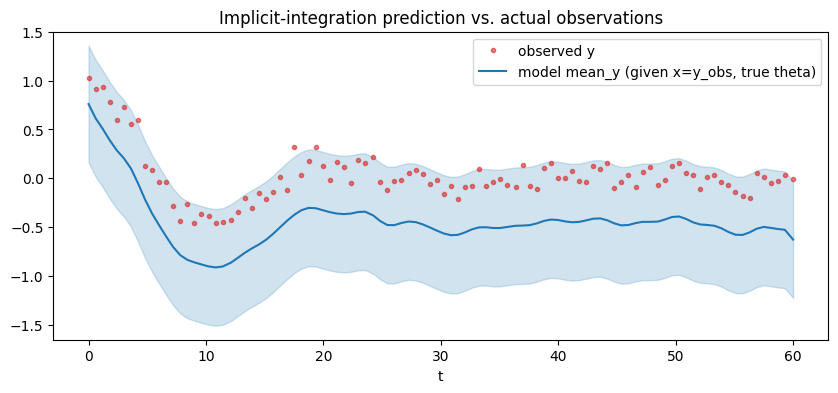

In [90]:
plt.figure(figsize=(10, 4))
plt.plot(t_obs, y_obs, '.', color='tab:red', label='observed y', alpha=0.6)
plt.plot(t_obs, dist_test.mean.detach(), color='tab:blue', label='model mean_y (given x=y_obs, true theta)')
plt.fill_between(t_obs,
                  dist_test.mean.detach() - 1.96*torch.sqrt(torch.diagonal(dist_test.covariance_matrix)),
                  dist_test.mean.detach() + 1.96*torch.sqrt(torch.diagonal(dist_test.covariance_matrix)),
                  alpha=0.2, color='tab:blue')
plt.legend(); plt.xlabel('t'); plt.title('Implicit-integration prediction vs. actual observations')
plt.show()

In [91]:
# theta grids
delta_grid  = torch.arange(0.02, 0.15+1e-9, 0.005)
omega0_grid = torch.arange(0.15, 0.45+1e-9, 0.01)

sigma_f2_grid = torch.linspace(0.1, 2.0, 10)
l_grid = torch.linspace(1.0, 50.0, 10)
sigma2_grid = torch.arange(0.001, 0.03+1e-9, 0.001) 

mu_phi = y_obs.mean()   # fixed, per paper footnote 3

print(f"delta_grid: {len(delta_grid)} points, [{delta_grid[0]:.3f}, {delta_grid[-1]:.3f}]")
print(f"omega0_grid: {len(omega0_grid)} points, [{omega0_grid[0]:.3f}, {omega0_grid[-1]:.3f}]")
print(f"sigma_f2_grid: {len(sigma_f2_grid)} points, [{sigma_f2_grid[0]:.4f}, {sigma_f2_grid[-1]:.4f}]")
print(f"l_grid: {len(l_grid)} points, [{l_grid[0]:.3f}, {l_grid[-1]:.3f}]")
print(f"sigma2_grid: {len(sigma2_grid)} points, [{sigma2_grid[0]:.3f}, {sigma2_grid[-1]:.3f}]")

delta_grid: 27 points, [0.020, 0.150]
omega0_grid: 31 points, [0.150, 0.450]
sigma_f2_grid: 10 points, [0.1000, 2.0000]
l_grid: 10 points, [1.000, 50.000]
sigma2_grid: 30 points, [0.001, 0.030]


In [92]:
n_bins_x = 20   # matches paper's own "20 uniformly spaced bins" (Section 5.1)
x_bandwidth = 3 * sigma_obs   # bins span y_k +/- 3*sigma

def x_grid_at(k):
    """20-bin grid for x(t_k), centered on the noisy observation y_k."""
    center = y_obs[k]
    return torch.linspace(center - x_bandwidth, center + x_bandwidth, n_bins_x)

# sanity check
print(x_grid_at(0))

tensor([0.7302, 0.7618, 0.7934, 0.8250, 0.8566, 0.8881, 0.9197, 0.9513, 0.9829,
        1.0145, 1.0460, 1.0776, 1.1092, 1.1408, 1.1724, 1.2039, 1.2355, 1.2671,
        1.2987, 1.3302])


In [93]:
theta_prior_mean = torch.tensor([0.1, 0.3])
theta_prior_cov_inv = torch.diag(torch.tensor([1/0.1**2, 1/0.2**2]))

def log_prior_theta(delta, omega0):
    diff = torch.tensor([delta, omega0]) - theta_prior_mean
    return (-0.5 * diff @ theta_prior_cov_inv @ diff).item()

sigma_prior_dist = torch.distributions.Gamma(concentration=1.0, rate=1.0)  # kept for sigma, per paper

def log_prior_phi(sigma_f2, l, sigma2):
    log_p_sf2 = 0.0 if 0 < sigma_f2 < 100 else -float('inf')
    log_p_l   = 0.0 if 0 < l < 100 else -float('inf')
    sigma = torch.sqrt(torch.tensor(sigma2))
    log_p_sigma = sigma_prior_dist.log_prob(sigma).item()
    return log_p_sf2 + log_p_l + log_p_sigma

In [94]:
def log_posterior_theta_phi(delta, omega0, sigma_f2, l, sigma2, x, y_obs, t_obs):
    C = build_covariance_blocks(t_obs, torch.log(torch.tensor(sigma_f2)), torch.log(torch.tensor(l)))
    dist = log_likelihood_y_given_x(x, delta, omega0, mu_phi, sigma2, C)
    log_lik = dist.log_prob(y_obs).item()
    return log_lik + log_prior_theta(delta, omega0) + log_prior_phi(sigma_f2, l, sigma2)


def gibbs_sweep_theta_phi(x_current, delta, omega0, sigma_f2, l, sigma2, t_obs, y_obs):
    """One pass of paper's Section 3.1: update each component in turn via a
    categorical draw over its discretized grid, holding all others fixed."""

    # --- delta ---
    log_probs = torch.tensor([
        log_posterior_theta_phi(d.item(), omega0, sigma_f2, l, sigma2, x_current, y_obs, t_obs)
        for d in delta_grid
    ])
    probs = torch.softmax(log_probs, dim=0)
    delta = delta_grid[torch.multinomial(probs, 1)].item()

    # --- omega0 ---
    log_probs = torch.tensor([
        log_posterior_theta_phi(delta, w.item(), sigma_f2, l, sigma2, x_current, y_obs, t_obs)
        for w in omega0_grid
    ])
    probs = torch.softmax(log_probs, dim=0)
    omega0 = omega0_grid[torch.multinomial(probs, 1)].item()

    # --- sigma_f2 ---
    log_probs = torch.tensor([
        log_posterior_theta_phi(delta, omega0, sf.item(), l, sigma2, x_current, y_obs, t_obs)
        for sf in sigma_f2_grid
    ])
    probs = torch.softmax(log_probs, dim=0)
    sigma_f2 = sigma_f2_grid[torch.multinomial(probs, 1)].item()

    # --- l ---
    log_probs = torch.tensor([
        log_posterior_theta_phi(delta, omega0, sigma_f2, lg.item(), sigma2, x_current, y_obs, t_obs)
        for lg in l_grid
    ])
    probs = torch.softmax(log_probs, dim=0)
    l = l_grid[torch.multinomial(probs, 1)].item()

    # --- sigma2 ---
    log_probs = torch.tensor([
        log_posterior_theta_phi(delta, omega0, sigma_f2, l, s2.item(), x_current, y_obs, t_obs)
        for s2 in sigma2_grid
    ])
    probs = torch.softmax(log_probs, dim=0)
    sigma2 = sigma2_grid[torch.multinomial(probs, 1)].item()

    return delta, omega0, sigma_f2, l, sigma2

In [95]:
x_test = y_obs.clone()
sigma_f2_stand_in, l_stand_in, sigma2_stand_in = 1.0, 25.0, 0.01
delta_new, omega0_new, sf2_new, l_new, s2_new = gibbs_sweep_theta_phi(
    x_test, delta_true, omega0_true, sigma_f2_stand_in, l_stand_in, sigma2_stand_in, t_obs, y_obs
)
print(f"delta: {delta_true:.4f} -> {delta_new:.4f}")
print(f"omega0: {omega0_true:.4f} -> {omega0_new:.4f}")
print(f"sigma_f2: {sigma_f2_star:.4f} -> {sf2_new:.4f}")
print(f"l: {l_star:.4f} -> {l_new:.4f}")
print(f"sigma2: {sigma2_star:.4f} -> {s2_new:.4f}")

delta: 0.0750 -> 0.1300
omega0: 0.3162 -> 0.1600
sigma_f2: 0.1800 -> 0.3111
l: 39.9775 -> 11.8889
sigma2: 0.0091 -> 0.0090


In [96]:
def gp_prior_conditional_at_t(k, x_current, mu_phi, C):
    """p_GP(x(t_k) | x_{\\t}, phi) -- standard single-point-out-of-n GP conditional."""
    n = len(x_current)
    idx_others = [i for i in range(n) if i != k]

    C_kk = C['xx'][k, k]
    C_k_others = C['xx'][k, idx_others]
    C_others_others = C['xx'][idx_others][:, idx_others]

    jitter = 1e-6
    L = torch.linalg.cholesky(C_others_others + jitter * torch.eye(n-1))
    x_others_centered = (x_current[idx_others] - mu_phi).unsqueeze(1)
    solved = torch.cholesky_solve(x_others_centered, L).squeeze(1)

    mean_k = mu_phi + C_k_others @ solved
    var_k = C_kk - C_k_others @ torch.cholesky_solve(C_k_others.unsqueeze(1), L).squeeze(1)
    var_k = torch.clamp(var_k, min=jitter)

    return mean_k, var_k


def sample_x_at_t(k, x_current, delta, omega0, mu_phi, sigma2, C, t_obs, y_obs):
    """One Gibbs step: propose values for x(t_k) on its discretized grid,
    score each via prior_conditional * full likelihood, sample categorically."""
    grid = x_grid_at(k)

    mean_k, var_k = gp_prior_conditional_at_t(k, x_current, mu_phi, C)
    prior_dist = torch.distributions.Normal(mean_k, torch.sqrt(var_k))

    log_probs = []
    for x_val in grid:
        x_proposal = x_current.clone()
        x_proposal[k] = x_val

        log_prior = prior_dist.log_prob(x_val)
        lik_dist = log_likelihood_y_given_x(x_proposal, delta, omega0, mu_phi, sigma2, C)
        log_lik = lik_dist.log_prob(y_obs)

        log_probs.append((log_prior + log_lik).item())

    log_probs = torch.tensor(log_probs)
    probs = torch.softmax(log_probs, dim=0)
    return grid[torch.multinomial(probs, 1)].item()


def gibbs_sweep_x(x_current, delta, omega0, mu_phi, sigma2, C, t_obs, y_obs):
    """One full sweep through all n time points (paper Section 3.2)."""
    x_new = x_current.clone()
    for k in range(len(x_current)):
        x_new[k] = sample_x_at_t(k, x_new, delta, omega0, mu_phi, sigma2, C, t_obs, y_obs)
    return x_new

In [97]:
import time
t0 = time.time()
C_stand_in = build_covariance_blocks(t_obs, torch.log(torch.tensor(1.0)), torch.log(torch.tensor(25.0)))
x_test_val = sample_x_at_t(0, y_obs.clone(), delta_true, omega0_true, mu_phi, 0.01, C_stand_in, t_obs, y_obs)
t1 = time.time()
print(f"one time-point update: {t1-t0:.3f}s, sampled value: {x_test_val:.4f}")

one time-point update: 0.065s, sampled value: 1.1408


In [98]:
def random_init_theta_phi(seed=0):
    torch.manual_seed(seed)
    delta0 = delta_grid[torch.randint(len(delta_grid), (1,))].item()
    omega0_0 = omega0_grid[torch.randint(len(omega0_grid), (1,))].item()
    sigma_f2_0 = sigma_f2_grid[torch.randint(len(sigma_f2_grid), (1,))].item()
    l0 = l_grid[torch.randint(len(l_grid), (1,))].item()
    sigma2_0 = sigma2_grid[torch.randint(len(sigma2_grid), (1,))].item()
    return (delta0, omega0_0), (sigma_f2_0, l0, sigma2_0)

init_theta, init_phi = random_init_theta_phi(seed=0)
print(f"random init_theta: {init_theta}")
print(f"random init_phi: {init_phi}")

random init_theta: (0.15, 0.45)
random init_phi: (0.7333333333333334, 1.0, 0.014000000000000002)


In [99]:
def run_gibbs(L, L_p, L_x, t_obs, y_obs, mu_phi, init_theta, init_phi, seed=0):
    torch.manual_seed(seed)
    delta, omega0 = init_theta
    sigma_f2, l, sigma2 = init_phi

    C0 = build_covariance_blocks(t_obs, torch.log(torch.tensor(sigma_f2)), torch.log(torch.tensor(l)))
    L0 = torch.linalg.cholesky(C0['xx'] + sigma2*torch.eye(len(t_obs)) + 1e-6*torch.eye(len(t_obs)))
    alpha0 = torch.cholesky_solve((y_obs - mu_phi).unsqueeze(1), L0).squeeze(1)
    x = mu_phi + C0['xx'] @ alpha0

    samples = {'delta': [], 'omega0': [], 'sigma_f2': [], 'l': [], 'sigma2': [], 'x_snapshot': []}

    for i in range(L):
        t0 = time.time()

        for _ in range(L_p):
            delta, omega0, sigma_f2, l, sigma2 = gibbs_sweep_theta_phi(
                x, delta, omega0, sigma_f2, l, sigma2, t_obs, y_obs
            )

        C = build_covariance_blocks(t_obs, torch.log(torch.tensor(sigma_f2)), torch.log(torch.tensor(l)))
        for _ in range(L_x):
            x = gibbs_sweep_x(x, delta, omega0, mu_phi, sigma2, C, t_obs, y_obs)

        samples['delta'].append(delta)
        samples['omega0'].append(omega0)
        samples['sigma_f2'].append(sigma_f2)
        samples['l'].append(l)
        samples['sigma2'].append(sigma2)
        samples['x_snapshot'].append(x.clone())

        print(f"iter {i+1}/{L}  delta={delta:.4f}  omega0={omega0:.4f}  ({time.time()-t0:.1f}s)")

    return samples

In [69]:
samples = run_gibbs(
    L=5, L_p=1, L_x=1,
    t_obs=t_obs, y_obs=y_obs, mu_phi=mu_phi,
    init_theta=init_theta,
    init_phi=init_phi
)

iter 1/5  delta=0.1300  omega0=0.3500  (6.2s)
iter 2/5  delta=0.1450  omega0=0.4000  (5.7s)
iter 3/5  delta=0.0600  omega0=0.4300  (5.6s)
iter 4/5  delta=0.1000  omega0=0.4300  (6.0s)
iter 5/5  delta=0.1300  omega0=0.3600  (5.8s)


In [70]:
samples = run_gibbs(
    L=30, L_p=1, L_x=1,
    t_obs=t_obs, y_obs=y_obs, mu_phi=mu_phi,
    init_theta=init_theta,
    init_phi=init_phi,
    seed=0
)

iter 1/30  delta=0.1300  omega0=0.3500  (6.8s)
iter 2/30  delta=0.1450  omega0=0.4000  (6.1s)
iter 3/30  delta=0.0600  omega0=0.4300  (5.5s)
iter 4/30  delta=0.1000  omega0=0.4300  (5.6s)
iter 5/30  delta=0.1300  omega0=0.3600  (5.8s)
iter 6/30  delta=0.1350  omega0=0.4000  (5.7s)
iter 7/30  delta=0.1100  omega0=0.2300  (5.6s)
iter 8/30  delta=0.0950  omega0=0.2600  (5.6s)
iter 9/30  delta=0.0250  omega0=0.2500  (8.1s)
iter 10/30  delta=0.0750  omega0=0.2800  (6.1s)
iter 11/30  delta=0.0800  omega0=0.1800  (5.3s)
iter 12/30  delta=0.0750  omega0=0.1700  (5.4s)
iter 13/30  delta=0.1100  omega0=0.1600  (5.7s)
iter 14/30  delta=0.1200  omega0=0.3500  (5.9s)
iter 15/30  delta=0.1500  omega0=0.3500  (5.5s)
iter 16/30  delta=0.0300  omega0=0.3300  (5.4s)
iter 17/30  delta=0.0950  omega0=0.3400  (5.0s)
iter 18/30  delta=0.1050  omega0=0.2900  (5.4s)
iter 19/30  delta=0.0350  omega0=0.1600  (5.3s)
iter 20/30  delta=0.0450  omega0=0.2200  (5.5s)
iter 21/30  delta=0.0500  omega0=0.3700  (5.6s)
i

mean |x change| between iter 26 and 30: 0.0193


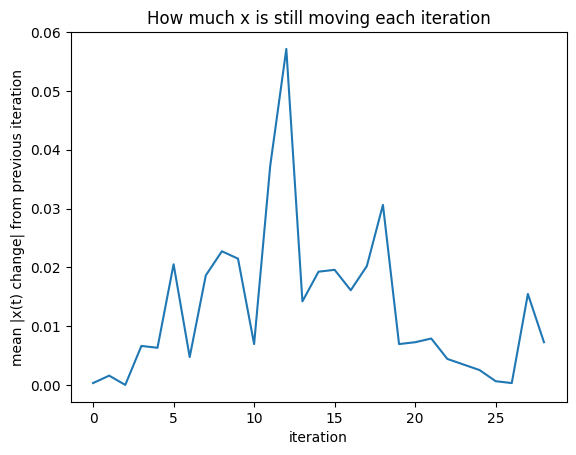

In [71]:
x_diff = (samples['x_snapshot'][-1] - samples['x_snapshot'][-5]).abs().mean()
print(f"mean |x change| between iter 26 and 30: {x_diff:.4f}")

# also worth seeing the trend across the whole run:
x_diffs_over_time = [(samples['x_snapshot'][i] - samples['x_snapshot'][i-1]).abs().mean().item()
                      for i in range(1, len(samples['x_snapshot']))]
plt.plot(x_diffs_over_time)
plt.xlabel('iteration'); plt.ylabel('mean |x(t) change| from previous iteration')
plt.title('How much x is still moving each iteration')
plt.show()

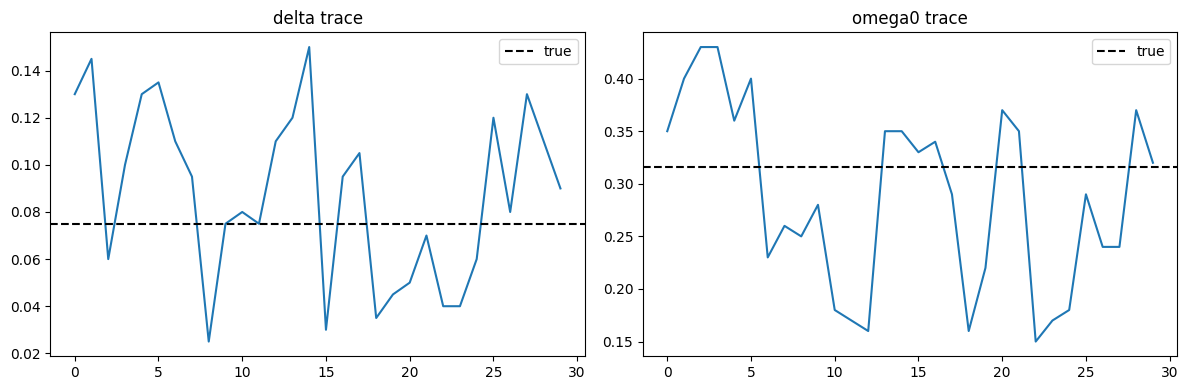

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(samples['delta'])
axes[0].axhline(delta_true, color='k', linestyle='--', label='true')
axes[0].set_title('delta trace'); axes[0].legend()

axes[1].plot(samples['omega0'])
axes[1].axhline(omega0_true, color='k', linestyle='--', label='true')
axes[1].set_title('omega0 trace'); axes[1].legend()
plt.tight_layout()
plt.show()

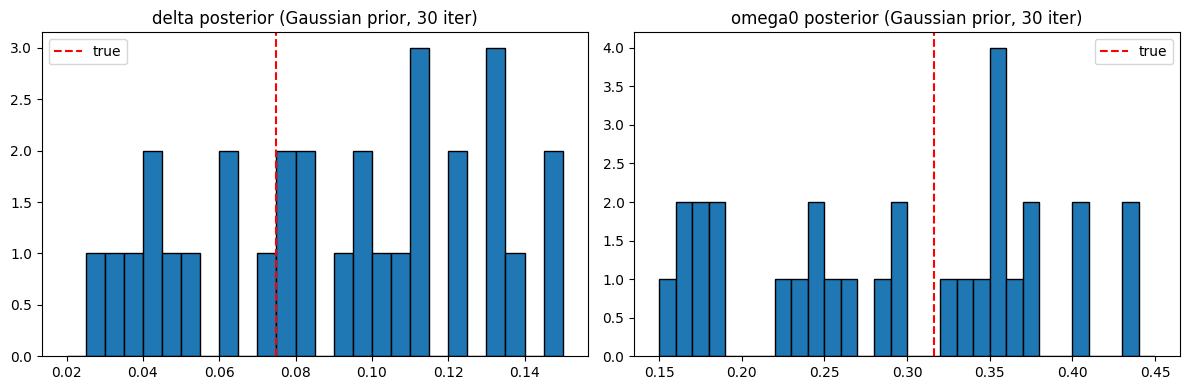

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(samples['delta'], bins=delta_grid.numpy(), edgecolor='k')
axes[0].axvline(delta_true, color='r', linestyle='--', label='true')
axes[0].set_title('delta posterior (Gaussian prior, 30 iter)'); axes[0].legend()

axes[1].hist(samples['omega0'], bins=omega0_grid.numpy(), edgecolor='k')
axes[1].axvline(omega0_true, color='r', linestyle='--', label='true')
axes[1].set_title('omega0 posterior (Gaussian prior, 30 iter)'); axes[1].legend()
plt.tight_layout()
plt.show()

In [100]:
samples = run_gibbs(
    L=200, L_p=1, L_x=1,
    t_obs=t_obs, y_obs=y_obs, mu_phi=mu_phi,
    init_theta=init_theta,
    init_phi=init_phi,
    seed=0
)

iter 1/200  delta=0.1300  omega0=0.3500  (5.4s)
iter 2/200  delta=0.1450  omega0=0.4000  (5.1s)
iter 3/200  delta=0.0600  omega0=0.4300  (5.1s)
iter 4/200  delta=0.1000  omega0=0.4300  (4.9s)
iter 5/200  delta=0.1300  omega0=0.3600  (5.0s)
iter 6/200  delta=0.1350  omega0=0.4000  (5.7s)
iter 7/200  delta=0.1100  omega0=0.2300  (5.2s)
iter 8/200  delta=0.0950  omega0=0.2600  (5.7s)
iter 9/200  delta=0.0250  omega0=0.2500  (5.4s)
iter 10/200  delta=0.0750  omega0=0.2800  (5.2s)
iter 11/200  delta=0.0800  omega0=0.1800  (5.2s)
iter 12/200  delta=0.0750  omega0=0.1700  (5.1s)
iter 13/200  delta=0.1100  omega0=0.1600  (5.3s)
iter 14/200  delta=0.1200  omega0=0.3500  (5.2s)
iter 15/200  delta=0.1500  omega0=0.3500  (5.0s)
iter 16/200  delta=0.0300  omega0=0.3300  (5.0s)
iter 17/200  delta=0.0950  omega0=0.3400  (5.2s)
iter 18/200  delta=0.1050  omega0=0.2900  (5.1s)
iter 19/200  delta=0.0350  omega0=0.1600  (5.0s)
iter 20/200  delta=0.0450  omega0=0.2200  (5.4s)
iter 21/200  delta=0.0500  om

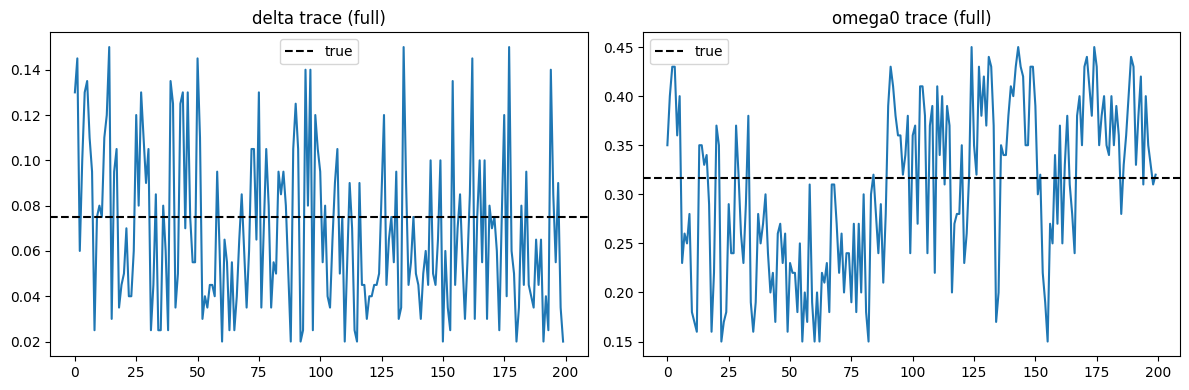

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(samples['delta'])
axes[0].axhline(delta_true, color='k', linestyle='--', label='true')
axes[0].set_title('delta trace (full)'); axes[0].legend()

axes[1].plot(samples['omega0'])
axes[1].axhline(omega0_true, color='k', linestyle='--', label='true')
axes[1].set_title('omega0 trace (full)'); axes[1].legend()
plt.tight_layout()
plt.show()

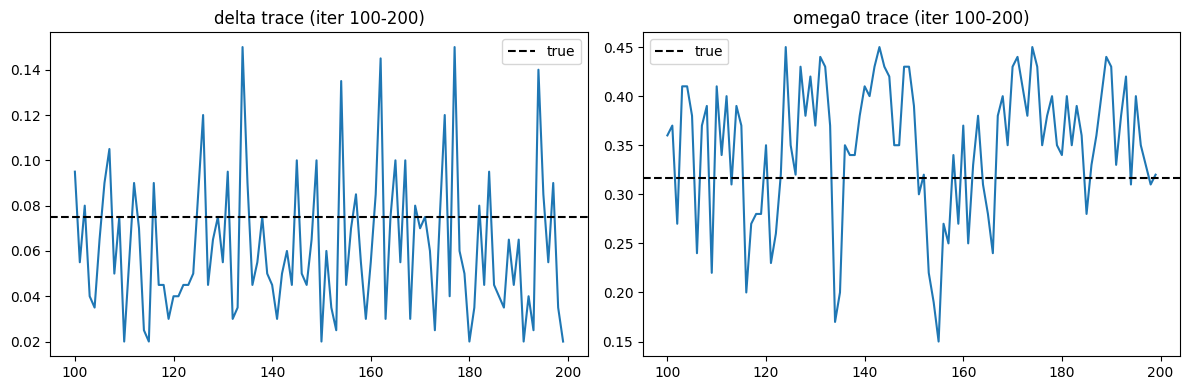

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(100, 200), samples['delta'][100:])
axes[0].axhline(delta_true, color='k', linestyle='--', label='true')
axes[0].set_title('delta trace (iter 100-200)'); axes[0].legend()

axes[1].plot(range(100, 200), samples['omega0'][100:])
axes[1].axhline(omega0_true, color='k', linestyle='--', label='true')
axes[1].set_title('omega0 trace (iter 100-200)'); axes[1].legend()
plt.tight_layout()
plt.show()

In [103]:
import numpy as np
delta_post = np.array(samples['delta'][100:])
omega0_post = np.array(samples['omega0'][100:])

print(f"delta:  mean={delta_post.mean():.4f}, std={delta_post.std():.4f}, true={delta_true}")
print(f"omega0: mean={omega0_post.mean():.4f}, std={omega0_post.std():.4f}, true={omega0_true}")

delta:  mean=0.0618, std=0.0307, true=0.075
omega0: mean=0.3491, std=0.0694, true=0.3162


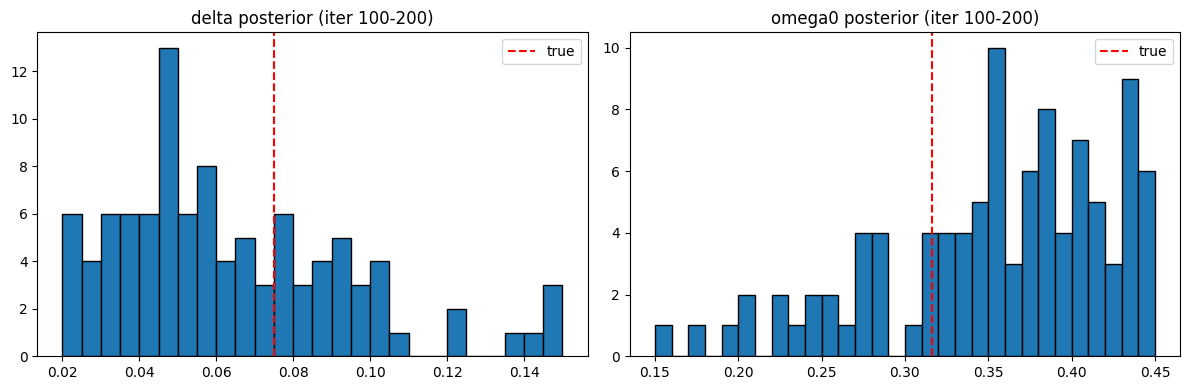

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(samples['delta'][100:], bins=delta_grid.numpy(), edgecolor='k')
axes[0].axvline(delta_true, color='r', linestyle='--', label='true')
axes[0].set_title('delta posterior (iter 100-200)'); axes[0].legend()

axes[1].hist(samples['omega0'][100:], bins=omega0_grid.numpy(), edgecolor='k')
axes[1].axvline(omega0_true, color='r', linestyle='--', label='true')
axes[1].set_title('omega0 posterior (iter 100-200)'); axes[1].legend()
plt.tight_layout()
plt.show()

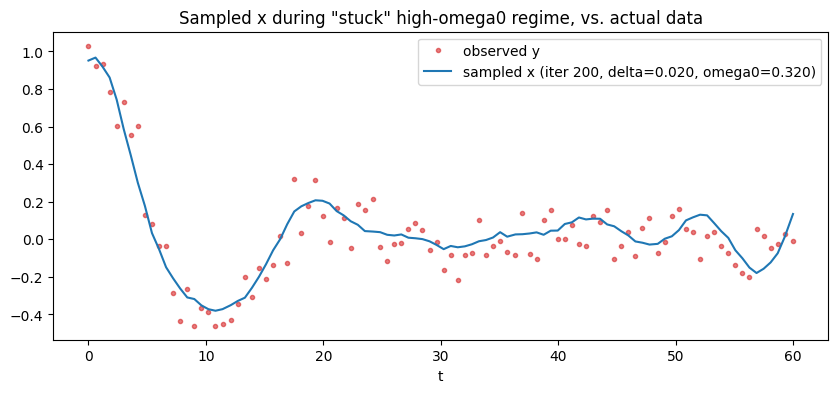

In [105]:
x_stuck = samples['x_snapshot'][-1]   # last iteration, deep in the omega0>0.30 regime

plt.figure(figsize=(10, 4))
plt.plot(t_obs, y_obs, '.', color='tab:red', label='observed y', alpha=0.6)
plt.plot(t_obs, x_stuck, color='tab:blue', label=f'sampled x (iter 200, delta={samples["delta"][-1]:.3f}, omega0={samples["omega0"][-1]:.3f})')
plt.legend(); plt.xlabel('t'); plt.title('Sampled x during "stuck" high-omega0 regime, vs. actual data')
plt.show()

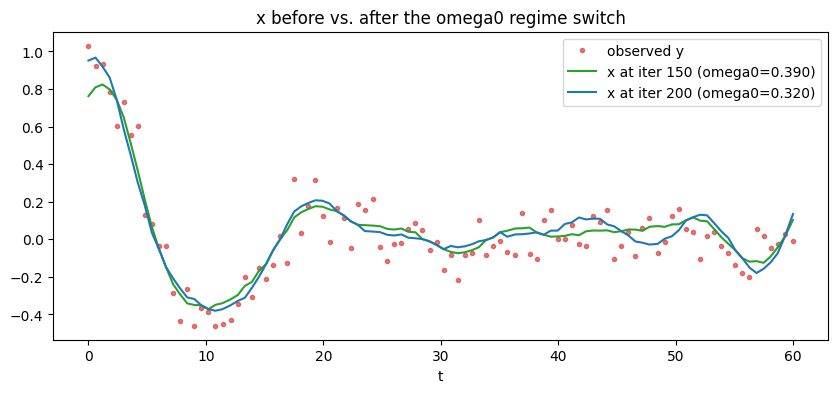

In [107]:
x_before_switch = samples['x_snapshot'][150]

plt.figure(figsize=(10, 4))
plt.plot(t_obs, y_obs, '.', color='tab:red', label='observed y', alpha=0.6)
plt.plot(t_obs, x_before_switch, color='tab:green', label=f'x at iter 150 (omega0={samples["omega0"][150]:.3f})')
plt.plot(t_obs, x_stuck, color='tab:blue', label=f'x at iter 200 (omega0={samples["omega0"][-1]:.3f})')
plt.legend(); plt.xlabel('t'); plt.title('x before vs. after the omega0 regime switch')
plt.show()

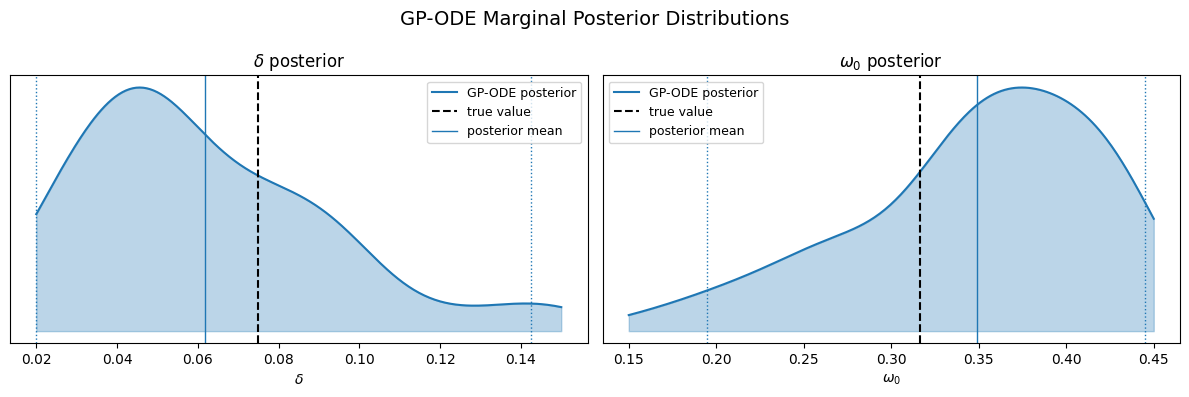

delta:  mean=0.0618, 95% CI=[0.0200, 0.1426], true=0.075
omega0: mean=0.3491, 95% CI=[0.1948, 0.4452], true=0.3162


In [108]:
import matplotlib.pyplot as pp
from scipy.stats import gaussian_kde

# use post-burn-in samples only
burn_in = 100
delta_post = np.array(samples['delta'][burn_in:])
omega0_post = np.array(samples['omega0'][burn_in:])

true_vals = [delta_true, omega0_true]
post_samples = [delta_post, omega0_post]
param_names = [r'$\delta$', r'$\omega_0$']

fig, axes = pp.subplots(1, 2, figsize=(12, 4))

for i, ax in enumerate(axes):
    samp = post_samples[i]
    kde = gaussian_kde(samp)
    x_grid = np.linspace(samp.min(), samp.max(), 300)
    density = kde(x_grid)

    ax.plot(x_grid, density, color='tab:blue', label='GP-ODE posterior')
    ax.fill_between(x_grid, density, alpha=0.3, color='tab:blue')

    mean_est = samp.mean()
    ci_lo, ci_hi = np.percentile(samp, [2.5, 97.5])
    ax.axvline(ci_lo, color='tab:blue', linestyle=':', linewidth=1)
    ax.axvline(ci_hi, color='tab:blue', linestyle=':', linewidth=1)

    ax.axvline(true_vals[i], color='k', linestyle='--', label='true value')
    ax.axvline(mean_est, color='tab:blue', linestyle='-', linewidth=1, label='posterior mean')

    ax.set_title(f'{param_names[i]} posterior')
    ax.set_xlabel(param_names[i])
    ax.set_yticks([])
    ax.legend(fontsize=9)

fig.suptitle('GP-ODE Marginal Posterior Distributions', fontsize=14)
pp.tight_layout()
pp.show()

print(f"delta:  mean={delta_post.mean():.4f}, 95% CI=[{np.percentile(delta_post,2.5):.4f}, {np.percentile(delta_post,97.5):.4f}], true={delta_true}")
print(f"omega0: mean={omega0_post.mean():.4f}, 95% CI=[{np.percentile(omega0_post,2.5):.4f}, {np.percentile(omega0_post,97.5):.4f}], true={omega0_true}")

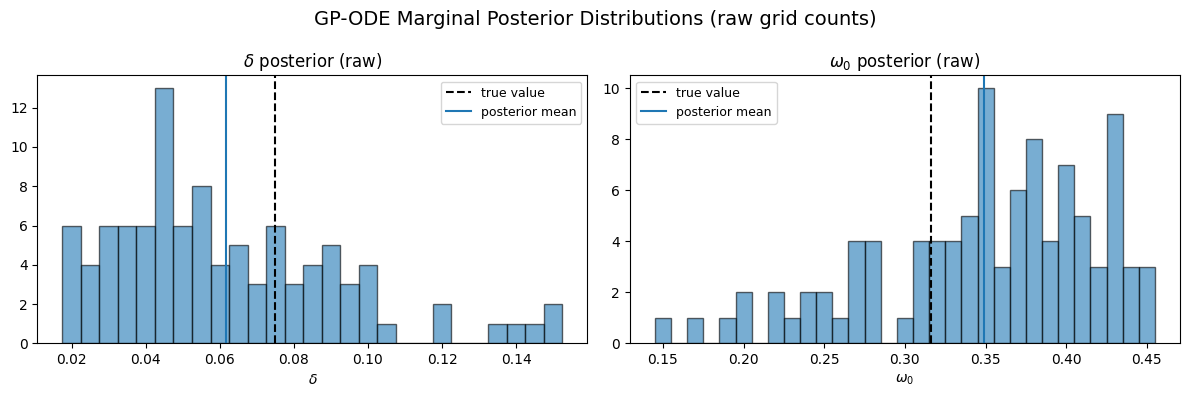

In [109]:
fig, axes = pp.subplots(1, 2, figsize=(12, 4))

grids = [delta_grid.numpy(), omega0_grid.numpy()]
posts = [delta_post, omega0_post]

for i, ax in enumerate(axes):
    # bin edges at the midpoints between grid points, so each bar sits on its exact grid value
    grid = grids[i]
    step = grid[1] - grid[0]
    bin_edges = np.concatenate([grid - step/2, [grid[-1] + step/2]])

    ax.hist(posts[i], bins=bin_edges, color='tab:blue', alpha=0.6, edgecolor='k')
    ax.axvline(true_vals[i], color='k', linestyle='--', label='true value')
    ax.axvline(posts[i].mean(), color='tab:blue', linestyle='-', linewidth=1.5, label='posterior mean')
    ax.set_title(f'{param_names[i]} posterior (raw)')
    ax.set_xlabel(param_names[i])
    ax.legend(fontsize=9)

fig.suptitle('GP-ODE Marginal Posterior Distributions (raw grid counts)', fontsize=14)
pp.tight_layout()
pp.show()

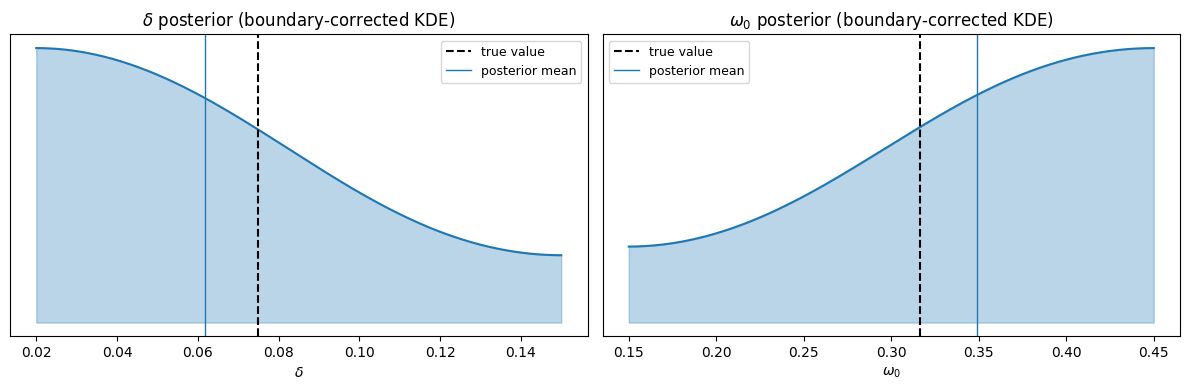

In [110]:
def reflected_kde(samples, lo, hi, grid_size=300):
    # reflect samples across both boundaries
    reflected_lo = 2*lo - samples
    reflected_hi = 2*hi - samples
    augmented = np.concatenate([samples, reflected_lo, reflected_hi])

    kde = gaussian_kde(augmented)
    x_grid = np.linspace(lo, hi, grid_size)
    density = kde(x_grid) * 3   # rescale: 3x the data now contributes, so density is 3x too high inside [lo,hi]
    return x_grid, density

fig, axes = pp.subplots(1, 2, figsize=(12, 4))
bounds = [(delta_grid[0].item(), delta_grid[-1].item()), (omega0_grid[0].item(), omega0_grid[-1].item())]

for i, ax in enumerate(axes):
    lo, hi = bounds[i]
    x_grid, density = reflected_kde(posts[i], lo, hi)
    ax.plot(x_grid, density, color='tab:blue')
    ax.fill_between(x_grid, density, alpha=0.3, color='tab:blue')
    ax.axvline(true_vals[i], color='k', linestyle='--', label='true value')
    ax.axvline(posts[i].mean(), color='tab:blue', linestyle='-', linewidth=1, label='posterior mean')
    ax.set_title(f'{param_names[i]} posterior (boundary-corrected KDE)')
    ax.set_xlabel(param_names[i])
    ax.set_yticks([])
    ax.legend(fontsize=9)

pp.tight_layout()
pp.show()